In [7]:
%pip install -q pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install -q seaborn
import seaborn as sns


In [8]:
#reading the data
df = pd.read_csv('creditcard.csv')
print(df.head().to_string())
print(df.columns)

   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28  Amount  Class
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169  1.468177 -0.470401  0.207971  0.025791  0.403993  0.251412 -0.018307  0.277838 -0.110474  0.066928  0.128539 -0.189115  0.133558 -0.021053  149.62      0
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803  0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095 -0.143772  0.635558  0.463917 -0.114805 -0.183361 -0.145783 -0.069083 -0.225775 -0.638672  0.101288 -0.339846  0.167170  0.125895 -0.008983  0.014724    2.69      0
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461  0.247676 -1.

In [9]:
#understanding the data
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

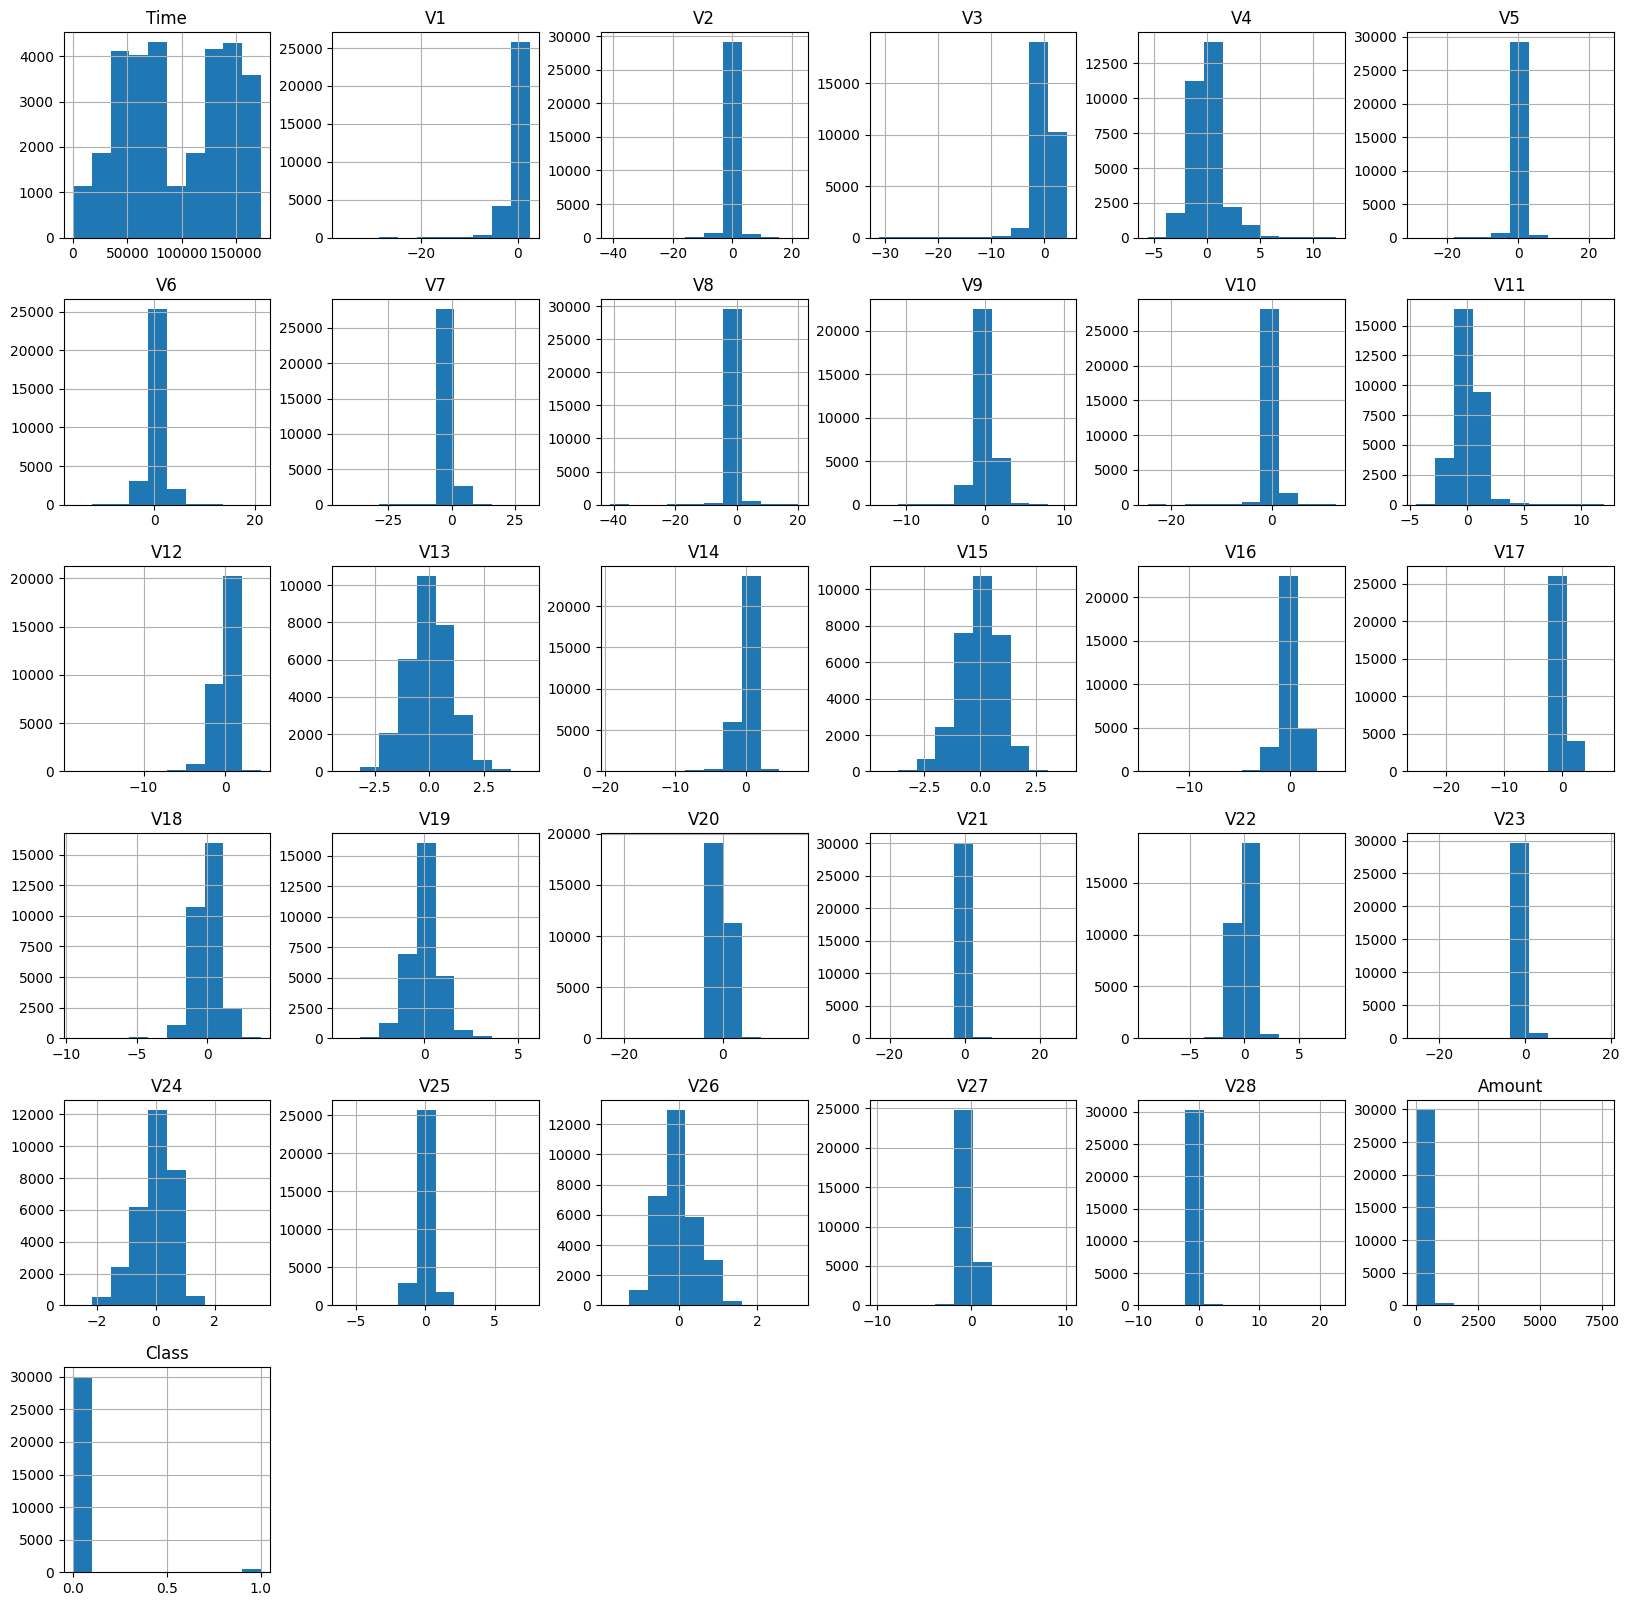

In [10]:
#now we will shorten the data since its a lot of data and to save on time
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0].sample(n=30000, random_state=1)
df = pd.concat([fraud, legit]).sample(frac=1, random_state=1).reset_index(drop=True)
df.hist(figsize=(20,20))
plt.show()

In [11]:
#now we will find the number of fraud and un fraud transactions
print('fraud cases',len(df[df['Class']==1]))
print('valid cases ',len(df[df['Class']==0]))
print('percentage fraud case',(len(df[df['Class']==1])/len(df[df['Class']==0]))*100 )



fraud cases 492
valid cases  30000
percentage fraud case 1.6400000000000001


In [12]:
#comparison btw amount of fraud and legitimate case
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,30000.0,88.414823,236.191997,0.0,5.8,21.995,76.07,7583.32
1,492.0,122.211321,256.683288,0.0,1.0,9.250,105.89,2125.87


In [13]:
#all other features are scaled except amount
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [14]:
#checking missing values and duplicated value
print(df.isnull().sum())
df=df.drop('Amount',axis=1)
df=df.drop('Time',axis=1)
print(df.duplicated().sum())
df=df.drop_duplicates()



Time             0
V1               0
V2               0
V3               0
V4               0
V5               0
V6               0
V7               0
V8               0
V9               0
V10              0
V11              0
V12              0
V13              0
V14              0
V15              0
V16              0
V17              0
V18              0
V19              0
V20              0
V21              0
V22              0
V23              0
V24              0
V25              0
V26              0
V27              0
V28              0
Amount           0
Class            0
Amount_scaled    0
dtype: int64
275


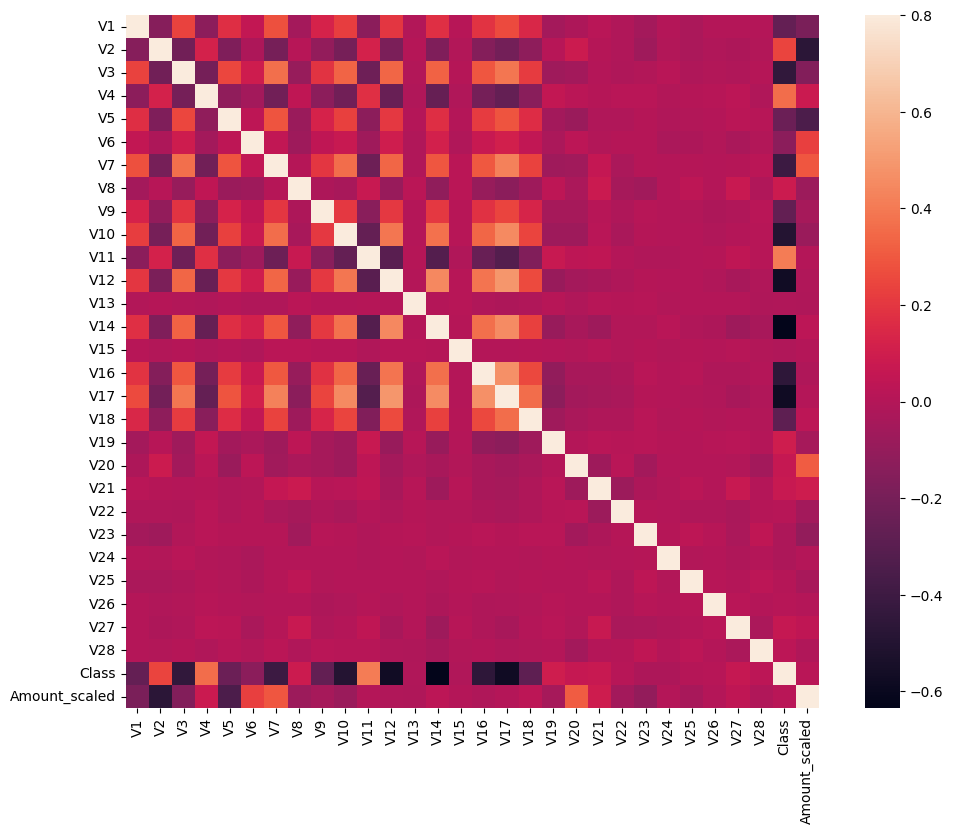

In [15]:
corrmat=df.corr()
fig=plt.figure(figsize=(12,9))
sns.heatmap(corrmat,vmax=.8,square=True)
plt.show()

In [16]:
#get all the columns from the dataframe
from sklearn.model_selection import train_test_split
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

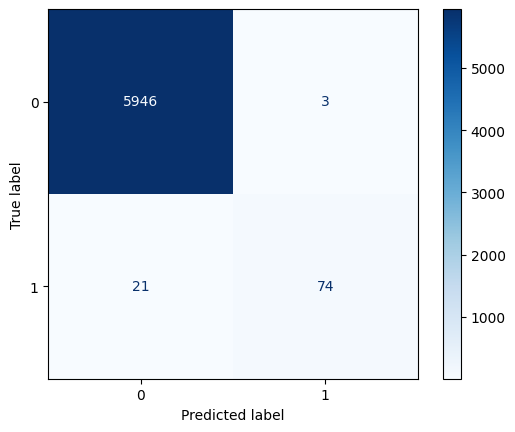

[[5946    3]
 [  21   74]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5949
           1       0.96      0.78      0.86        95

    accuracy                           1.00      6044
   macro avg       0.98      0.89      0.93      6044
weighted avg       1.00      1.00      1.00      6044

0.9960291197882197


In [18]:
#FALSE METRICS TEST FOR IMBALANCED DATA
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
plt.show()
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))


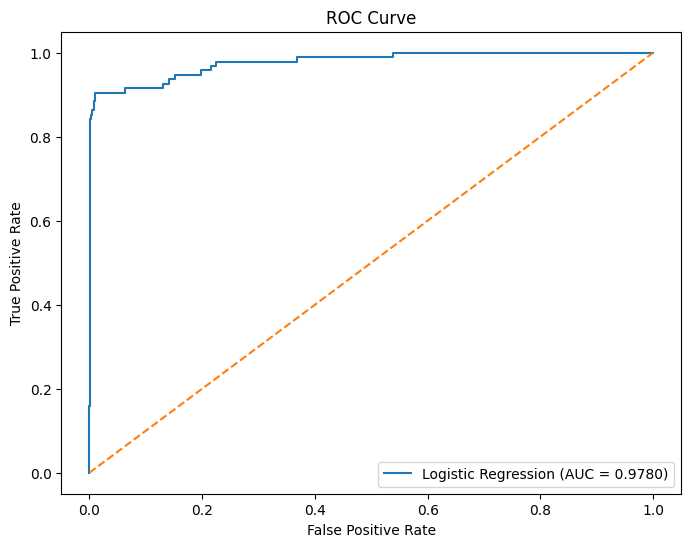

Threshold: [2.37079091e-01 2.31553322e-01 2.26776839e-01 1.64735199e-01
 1.44285481e-01 7.73115240e-02 7.46368403e-02 5.59259963e-02
 5.42517514e-02 4.10647966e-02 4.08085729e-02 3.56256376e-02
 3.42237041e-02 2.79584235e-02 2.78827732e-02 2.73096093e-02
 2.72246532e-02 7.24684978e-03 7.23841487e-03 4.00507038e-03
 4.00234077e-03 3.72748099e-03 3.72604597e-03 3.48572181e-03
 3.48179093e-03 2.64650304e-03 2.64647626e-03 2.41158405e-03
 2.41129947e-03 2.30718045e-03 2.30644118e-03 1.28722238e-03
 1.28720582e-03 7.37152278e-04 7.37152103e-04 2.04183078e-11]
Recall: [0.82105263 0.82105263 0.83157895 0.83157895 0.84210526 0.84210526
 0.85263158 0.85263158 0.86315789 0.86315789 0.87368421 0.87368421
 0.88421053 0.88421053 0.89473684 0.89473684 0.90526316 0.90526316
 0.91578947 0.91578947 0.92631579 0.92631579 0.93684211 0.93684211
 0.94736842 0.94736842 0.95789474 0.95789474 0.96842105 0.96842105
 0.97894737 0.97894737 0.98947368 0.98947368 1.         1.        ]
FPR: [6.72381913e-04 8.40477

In [19]:
#plotting roc curve
from sklearn.metrics import roc_curve,roc_auc_score
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
target_recall = 0.80

valid = np.where(tpr >= target_recall)

best_idx = valid[np.argmin(fpr[valid])]

threshold = thresholds[best_idx]

print("Threshold:", threshold)
print("Recall:", tpr[best_idx])
print("FPR:", fpr[best_idx])

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = average_precision_score(y_test, y_prob)

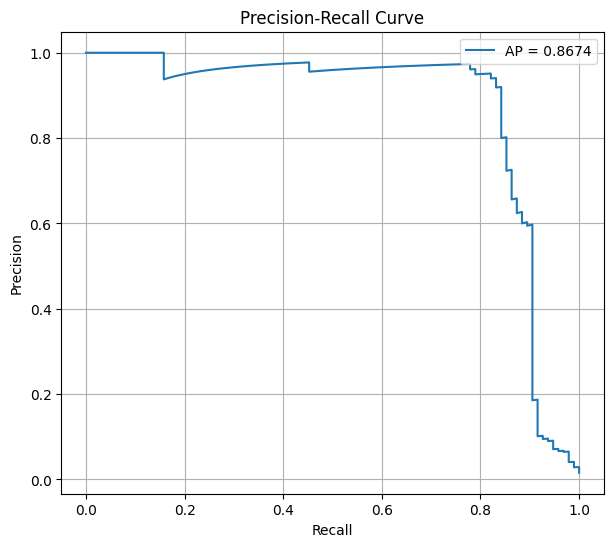

In [21]:
plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    label=f"AP = {pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()

plt.show()

In [22]:
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds_to_test = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds_to_test:

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred
    ).ravel()

    results.append([
        threshold,
        precision,
        recall,
        f1,
        fp,
        fn,
        tp
    ])

In [23]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "FP",
        "FN",
        "TP"
    ]
)

results_df

,Threshold,Precision,Recall,F1,FP,FN,TP
0,0.05,0.719298,0.863158,0.784689,32,13,82
1,0.10,0.842105,0.842105,0.842105,15,15,80
2,0.15,0.918605,0.831579,0.872928,7,16,79
3,0.20,0.940476,0.831579,0.882682,5,16,79
4,0.25,0.950000,0.800000,0.868571,4,19,76
5,0.30,0.949367,0.789474,0.862069,4,20,75
6,0.35,0.961538,0.789474,0.867052,3,20,75
7,0.40,0.961039,0.778947,0.860465,3,21,74
8,0.45,0.961039,0.778947,0.860465,3,21,74
9,0.50,0.961039,0.778947,0.860465,3,21,74


In [24]:
#best model for LR is the the one with 0.90 threshold
#training second model
from sklearn.ensemble import RandomForestClassifier
model2=RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
model2.fit(X_train,y_train)
y_pred2=model2.predict(X_test)

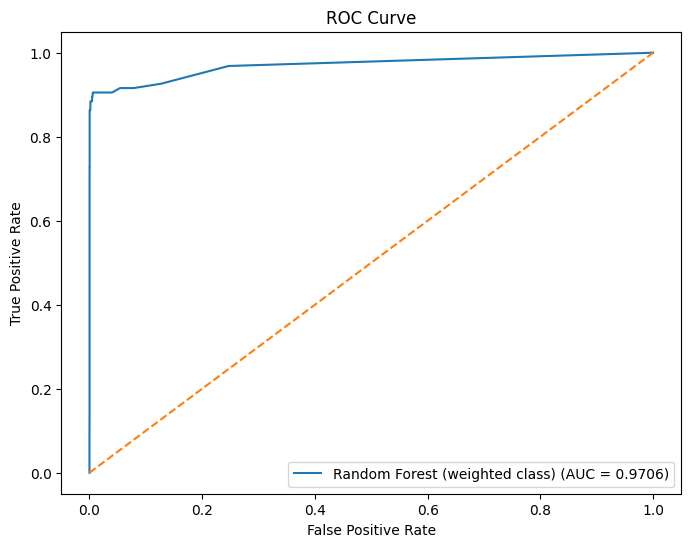

Threshold: [0.39333333 0.21333333 0.12       0.10666667 0.1        0.09333333
 0.09       0.08       0.07666667 0.07333333 0.07       0.06666667
 0.06333333 0.05666667 0.05333333 0.05       0.04666667 0.04333333
 0.04       0.03666667 0.03333333 0.03       0.02666667 0.02333333
 0.02       0.01666667 0.01333333 0.01       0.00666667 0.00333333
 0.        ]
Recall: [0.81052632 0.86315789 0.86315789 0.87368421 0.88421053 0.88421053
 0.88421053 0.88421053 0.88421053 0.88421053 0.88421053 0.88421053
 0.88421053 0.88421053 0.89473684 0.89473684 0.90526316 0.90526316
 0.90526316 0.90526316 0.90526316 0.90526316 0.90526316 0.90526316
 0.90526316 0.90526316 0.91578947 0.91578947 0.92631579 0.96842105
 1.        ]
FPR: [3.36190956e-04 3.36190956e-04 1.51285930e-03 1.68095478e-03
 1.68095478e-03 2.01714574e-03 2.18524122e-03 2.85762313e-03
 3.02571861e-03 3.36190956e-03 3.53000504e-03 3.86619600e-03
 4.03429148e-03 4.53857791e-03 4.87476887e-03 5.21095983e-03
 6.05143722e-03 7.39620104e-03 7.900

In [25]:
#plotting roc curve
from sklearn.metrics import roc_curve,roc_auc_score
y_prob2 = model2.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob2)

roc_auc = roc_auc_score(y_test, y_prob2)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (weighted class) (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
target_recall = 0.80

valid = np.where(tpr >= target_recall)

best_idx = valid[np.argmin(fpr[valid])]

threshold = thresholds[best_idx]

print("Threshold:", threshold)
print("Recall:", tpr[best_idx])
print("FPR:", fpr[best_idx])

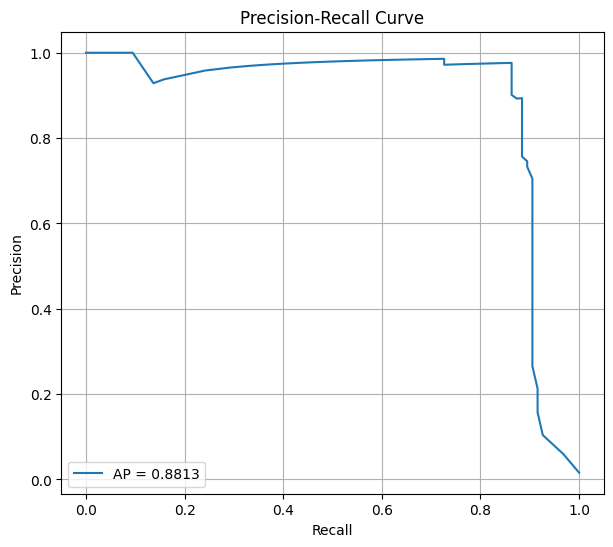

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob2
)

pr_auc = average_precision_score(y_test, y_prob2)
plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    label=f"AP = {pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()

plt.show()

In [27]:
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
y_prob2 = model2.predict_proba(X_test)[:, 1]
thresholds_to_test = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds_to_test:

    y_pred2 = (y_prob2 >= threshold).astype(int)

    precision = precision_score(y_test, y_pred2, zero_division=0)
    recall = recall_score(y_test, y_pred2, zero_division=0)
    f1 = f1_score(y_test, y_pred2, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred2
    ).ravel()

    results.append([
        threshold,
        precision,
        recall,
        f1,
        fp,
        fn,
        tp
    ])

In [28]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "FP",
        "FN",
        "TP"
    ]
)

results_df

,Threshold,Precision,Recall,F1,FP,FN,TP
0,0.05,0.732759,0.894737,0.805687,31,10,85
1,0.10,0.893617,0.884211,0.888889,10,11,84
2,0.15,0.931818,0.863158,0.896175,6,13,82
3,0.20,0.964706,0.863158,0.911111,3,13,82
4,0.25,0.975309,0.831579,0.897727,2,16,79
5,0.30,0.975000,0.821053,0.891429,2,17,78
6,0.35,0.975000,0.821053,0.891429,2,17,78
7,0.40,0.974026,0.789474,0.872093,2,20,75
8,0.45,0.973684,0.778947,0.865497,2,21,74
9,0.50,0.973684,0.778947,0.865497,2,21,74


In [29]:
lr_prob = model.predict_proba(X_test)[:, 1]
rf_prob = model2.predict_proba(X_test)[:, 1]

lr_pred = (lr_prob >= 0.90).astype(int)
rf_pred = (rf_prob >= 0.15).astype(int)
comparison = pd.DataFrame({
    "actual": y_test.values,
    "LR_pred": lr_pred,
    "RF_pred": rf_pred
})

comparison[comparison["actual"] == 1]

,actual,LR_pred,RF_pred
137,1,1,1
302,1,0,0
320,1,1,1
325,1,0,1
330,1,1,1
...,...,...,...
5856,1,0,1
5906,1,1,1
5918,1,1,1
5938,1,1,1


In [30]:
#Using Xgboost for this kinda chic
from xgboost import XGBClassifier
model3=XGBClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
model3.fit(X_train,y_train)
y_pred3=model3.predict(X_test)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [06:28:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


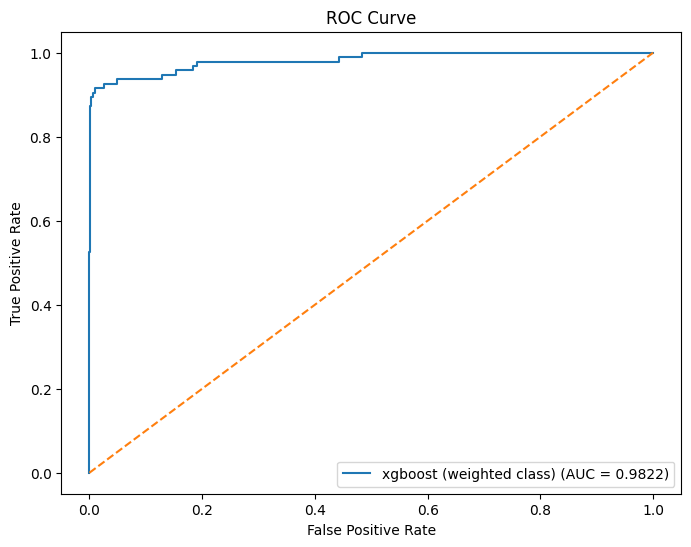

Threshold: [9.92007613e-01 9.90392864e-01 9.84535277e-01 9.14048612e-01
 4.38103020e-01 2.01260418e-01 1.66144803e-01 8.48613009e-02
 7.61776343e-02 2.90960241e-02 2.66698543e-02 1.21455742e-02
 1.16396565e-02 3.81425489e-03 3.74769140e-03 2.05555535e-03
 2.02704081e-03 1.97927584e-03 1.97608350e-03 4.73300839e-04
 4.70775267e-04 2.01575735e-04 2.00453345e-04 8.47941410e-05
 8.46787516e-05 7.27358420e-05 7.24480778e-05 4.59063122e-05
 4.57999668e-05 3.30582479e-05 3.29913564e-05 2.38036901e-05
 2.37671484e-05 2.22846575e-05 2.22775598e-05 6.89040326e-06
 6.88123600e-06 6.84851466e-06 6.83208918e-06 4.19831485e-06
 4.19724984e-06 3.43337115e-06 3.42695625e-06 2.06932623e-06
 2.06733785e-06 1.59282399e-06 1.59041520e-06 1.34515369e-06
 1.34381753e-06 1.03513048e-06 1.03452260e-06 8.72584849e-07
 8.71983332e-07 8.40628047e-07 8.40268171e-07 8.12594237e-07
 8.09822325e-07 6.45170360e-07 6.45086686e-07 5.05002959e-07
 5.04555715e-07 2.76124382e-07 2.75338408e-07 2.58214840e-07
 2.57518622e-

In [31]:
#plotting roc curve
from sklearn.metrics import roc_curve,roc_auc_score
y_prob3 = model3.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob3)

roc_auc = roc_auc_score(y_test, y_prob3)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"xgboost (weighted class) (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
target_recall = 0.80

valid = np.where(tpr >= target_recall)

best_idx = valid[np.argmin(fpr[valid])]

threshold = thresholds[best_idx]

print("Threshold:", threshold)
print("Recall:", tpr[best_idx])
print("FPR:", fpr[best_idx])

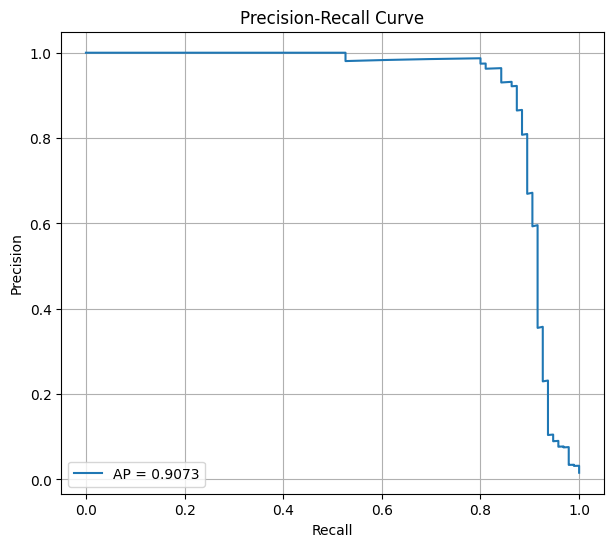

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob3
)

pr_auc = average_precision_score(y_test, y_prob3)
plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    label=f"AP = {pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()

plt.show()

In [33]:
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
y_prob3 = model3.predict_proba(X_test)[:, 1]
thresholds_to_test = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds_to_test:

    y_pred3 = (y_prob3 >= threshold).astype(int)

    precision = precision_score(y_test, y_pred3, zero_division=0)
    recall = recall_score(y_test, y_pred3, zero_division=0)
    f1 = f1_score(y_test, y_pred3, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred3
    ).ravel()

    results.append([
        threshold,
        precision,
        recall,
        f1,
        fp,
        fn,
        tp
    ])

In [34]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "FP",
        "FN",
        "TP"
    ]
)

results_df

,Threshold,Precision,Recall,F1,FP,FN,TP
0,0.05,0.892473,0.873684,0.882979,10,12,83
1,0.10,0.931818,0.863158,0.896175,6,13,82
2,0.15,0.931818,0.863158,0.896175,6,13,82
3,0.20,0.930233,0.842105,0.883978,6,15,80
4,0.25,0.963855,0.842105,0.898876,3,15,80
5,0.30,0.963855,0.842105,0.898876,3,15,80
6,0.35,0.963855,0.842105,0.898876,3,15,80
7,0.40,0.963855,0.842105,0.898876,3,15,80
8,0.45,0.963415,0.831579,0.892655,3,16,79
9,0.50,0.963415,0.831579,0.892655,3,16,79


In [35]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve,roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.base import clone
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_aucs = []
rf_aucs = []
xgb_aucs = []
lr_pr_aucs = []
rf_pr_aucs = []
xgb_pr_aucs = []
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(scale_pos_weight)

model_1=XGBClassifier(
    n_estimators=300,


    random_state=42,
    n_jobs=-1
)
model_2=RandomForestClassifier(
    n_estimators=300,

    random_state=42,
    n_jobs=-1
)
model_3=LogisticRegression()



oof_rf = np.zeros(len(y_train))
oof_xgb = np.zeros(len(y_train))
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
  print(f"Fold {fold}")

    # Handle both pandas DataFrame and NumPy array
  X_tr = X_train.iloc[train_idx]
  X_val = X_train.iloc[val_idx]

  y_tr = y_train.iloc[train_idx]
  y_val = y_train.iloc[val_idx]


  # --------------------------------------------------
  # Random Forest
  # --------------------------------------------------

  rf = clone(model_2)

  rf.fit(X_tr, y_tr)

  oof_rf[val_idx] = rf.predict_proba(X_val)[:, 1]


  # --------------------------------------------------
  # XGBoost
  # --------------------------------------------------

  xgb = clone(model_1)

  xgb.fit(X_tr, y_tr)

  oof_xgb[val_idx] = xgb.predict_proba(X_val)[:, 1]


62.94973544973545
Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [36]:
rf_roc_auc = roc_auc_score(y_train, oof_rf)
rf_ap = average_precision_score(y_train, oof_rf)

xgb_roc_auc = roc_auc_score(y_train, oof_xgb)
xgb_ap = average_precision_score(y_train, oof_xgb)

In [37]:
print("Random Forest")
print("--------------------")
print("ROC-AUC:", rf_roc_auc)
print("AP:", rf_ap)

print("\nXGBoost")
print("--------------------")
print("ROC-AUC:", xgb_roc_auc)
print("AP:", xgb_ap)

Random Forest
--------------------
ROC-AUC: 0.968518240571193
AP: 0.8743369082068636

XGBoost
--------------------
ROC-AUC: 0.9804283946540723
AP: 0.8935143139137062


In [38]:
print(X.shape)
print(y.value_counts())


(30217, 29)
Class
0    29744
1      473
Name: count, dtype: int64


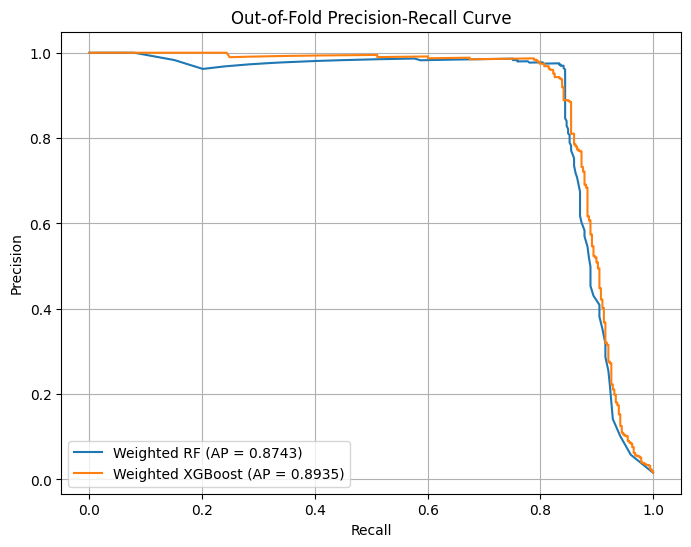

In [39]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

rf_precision, rf_recall, _ = precision_recall_curve(
    y_train,
    oof_rf
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_train,
    oof_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    rf_recall,
    rf_precision,
    label=f"Weighted RF (AP = {rf_ap:.4f})"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label=f"Weighted XGBoost (AP = {xgb_ap:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Out-of-Fold Precision-Recall Curve")

plt.legend()
plt.grid()

plt.show()

In [40]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def threshold_table(y_true, probabilities):

    thresholds = np.arange(0.01, 1.00, 0.01)

    results = []

    for threshold in thresholds:

        # Convert probability to class prediction
        y_pred = (probabilities >= threshold).astype(int)

        # Metrics
        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        results.append({
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

    return pd.DataFrame(results)

In [41]:
rf_results = threshold_table(y_train, oof_rf)
rf_results

,Threshold,Precision,Recall,F1,TN,FP,FN,TP
0,0.01,0.141304,0.928571,0.245283,21662,2133,27,351
1,0.02,0.254758,0.920635,0.399083,22777,1018,30,348
2,0.03,0.352821,0.910053,0.508500,23164,631,34,344
3,0.04,0.430573,0.894180,0.581255,23348,447,40,338
4,0.05,0.498516,0.888889,0.638783,23457,338,42,336
...,...,...,...,...,...,...,...,...
94,0.95,0.985782,0.550265,0.706282,23792,3,170,208
95,0.96,0.984694,0.510582,0.672474,23792,3,185,193
96,0.97,0.982558,0.447090,0.614545,23792,3,209,169
97,0.98,0.977444,0.343915,0.508806,23792,3,248,130


In [42]:
xgb_results = threshold_table(y_train, oof_xgb)
xgb_results


,Threshold,Precision,Recall,F1,TN,FP,FN,TP
0,0.01,0.769231,0.873016,0.817844,23696,99,48,330
1,0.02,0.838961,0.854497,0.846658,23733,62,55,323
2,0.03,0.870620,0.854497,0.862483,23747,48,55,323
3,0.04,0.887052,0.851852,0.869096,23754,41,56,322
4,0.05,0.890756,0.841270,0.865306,23756,39,60,318
...,...,...,...,...,...,...,...,...
94,0.95,0.977273,0.796296,0.877551,23788,7,77,301
95,0.96,0.983607,0.793651,0.878477,23790,5,78,300
96,0.97,0.983553,0.791005,0.876833,23790,5,79,299
97,0.98,0.986622,0.780423,0.871492,23791,4,83,295


In [43]:
rf_results[rf_results["Recall"] >= 0.70].sort_values(
    "Precision",
    ascending=False
)

,Threshold,Precision,Recall,F1,TN,FP,FN,TP
80,0.81,0.986111,0.751323,0.852853,23791,4,94,284
79,0.80,0.986111,0.751323,0.852853,23791,4,94,284
81,0.82,0.985915,0.740741,0.845921,23791,4,98,280
82,0.83,0.985816,0.735450,0.842424,23791,4,100,278
83,0.84,0.985714,0.730159,0.838906,23791,4,102,276
...,...,...,...,...,...,...,...,...
4,0.05,0.498516,0.888889,0.638783,23457,338,42,336
3,0.04,0.430573,0.894180,0.581255,23348,447,40,338
2,0.03,0.352821,0.910053,0.508500,23164,631,34,344
1,0.02,0.254758,0.920635,0.399083,22777,1018,30,348


In [44]:
xgb_results[xgb_results["Recall"] >= 0.70].sort_values(
    "Precision",
    ascending=False
)

,Threshold,Precision,Recall,F1,TN,FP,FN,TP
97,0.98,0.986622,0.780423,0.871492,23791,4,83,295
98,0.99,0.986159,0.753968,0.854573,23791,4,93,285
95,0.96,0.983607,0.793651,0.878477,23790,5,78,300
96,0.97,0.983553,0.791005,0.876833,23790,5,79,299
91,0.92,0.977346,0.798942,0.879185,23788,7,76,302
...,...,...,...,...,...,...,...,...
4,0.05,0.890756,0.841270,0.865306,23756,39,60,318
3,0.04,0.887052,0.851852,0.869096,23754,41,56,322
2,0.03,0.870620,0.854497,0.862483,23747,48,55,323
1,0.02,0.838961,0.854497,0.846658,23733,62,55,323


In [45]:
#now testing with smote
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

In [46]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
import numpy as np

skf2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_rf_smote = np.zeros(len(y_train))
oof_xgb_smote = np.zeros(len(y_train))

for fold, (train_idx, val_idx) in enumerate(
    skf2.split(X_train, y_train), 1
):

    print(f"Fold {fold}")

    # -------------------------
    # Split fold
    # -------------------------

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    print("Before SMOTE:")
    print(y_tr.value_counts())

    # -------------------------
    # Apply SMOTE ONLY to
    # training fold
    # -------------------------

    smote = SMOTE(
        random_state=42
    )

    X_tr_smote, y_tr_smote = smote.fit_resample(
        X_tr,
        y_tr
    )

    print("After SMOTE:")
    print(pd.Series(y_tr_smote).value_counts())

    # -------------------------
    # Random Forest
    # -------------------------

    rf = clone(model_2)

    rf.fit(
        X_tr_smote,
        y_tr_smote
    )

    oof_rf_smote[val_idx] = rf.predict_proba(
        X_val
    )[:, 1]

    # -------------------------
    # XGBoost
    # -------------------------

    xgb = clone(model_1)

    xgb.fit(
        X_tr_smote,
        y_tr_smote
    )

    oof_xgb_smote[val_idx] = xgb.predict_proba(
        X_val
    )[:, 1]

Fold 1
Before SMOTE:
Class
0    19036
1      302
Name: count, dtype: int64
After SMOTE:
Class
0    19036
1    19036
Name: count, dtype: int64
Fold 2
Before SMOTE:
Class
0    19036
1      302
Name: count, dtype: int64
After SMOTE:
Class
0    19036
1    19036
Name: count, dtype: int64
Fold 3
Before SMOTE:
Class
0    19036
1      302
Name: count, dtype: int64
After SMOTE:
Class
0    19036
1    19036
Name: count, dtype: int64
Fold 4
Before SMOTE:
Class
0    19036
1      303
Name: count, dtype: int64
After SMOTE:
Class
0    19036
1    19036
Name: count, dtype: int64
Fold 5
Before SMOTE:
Class
0    19036
1      303
Name: count, dtype: int64
After SMOTE:
Class
0    19036
1    19036
Name: count, dtype: int64


In [47]:
print("\nRandom Forest + SMOTE")
print("--------------------")

print(
    "ROC-AUC:",
    roc_auc_score(y_train, oof_rf_smote)
)

print(
    "AP:",
    average_precision_score(y_train, oof_rf_smote)
)


print("\nXGBoost + SMOTE")
print("--------------------")

print(
    "ROC-AUC:",
    roc_auc_score(y_train, oof_xgb_smote)
)

print(
    "AP:",
    average_precision_score(y_train, oof_xgb_smote)
)


Random Forest + SMOTE
--------------------
ROC-AUC: 0.9822035886335109
AP: 0.8936467529818773

XGBoost + SMOTE
--------------------
ROC-AUC: 0.9785102801597862
AP: 0.8916649367682525


In [48]:
xgb_smote_results = threshold_table(
    y_train,
    oof_xgb_smote
)


In [49]:
xgb_smote_results[
    xgb_smote_results["Recall"] >= 0.70
].sort_values(
    "Precision",
    ascending=False
)

,Threshold,Precision,Recall,F1,TN,FP,FN,TP
98,0.99,0.974843,0.820106,0.890805,23787,8,68,310
97,0.98,0.965839,0.822751,0.888571,23784,11,67,311
96,0.97,0.962963,0.825397,0.888889,23783,12,66,312
95,0.96,0.962963,0.825397,0.888889,23783,12,66,312
94,0.95,0.960366,0.833333,0.892351,23782,13,63,315
...,...,...,...,...,...,...,...,...
4,0.05,0.676230,0.873016,0.762125,23637,158,48,330
3,0.04,0.645793,0.873016,0.742407,23614,181,48,330
2,0.03,0.610294,0.878307,0.720174,23583,212,46,332
1,0.02,0.568259,0.880952,0.690871,23542,253,45,333


In [50]:
xgb_smote_results[
    xgb_smote_results["Recall"] >= 0.70

].sort_values(
    "Precision",
    ascending=False
)

,Threshold,Precision,Recall,F1,TN,FP,FN,TP
98,0.99,0.974843,0.820106,0.890805,23787,8,68,310
97,0.98,0.965839,0.822751,0.888571,23784,11,67,311
96,0.97,0.962963,0.825397,0.888889,23783,12,66,312
95,0.96,0.962963,0.825397,0.888889,23783,12,66,312
94,0.95,0.960366,0.833333,0.892351,23782,13,63,315
...,...,...,...,...,...,...,...,...
4,0.05,0.676230,0.873016,0.762125,23637,158,48,330
3,0.04,0.645793,0.873016,0.742407,23614,181,48,330
2,0.03,0.610294,0.878307,0.720174,23583,212,46,332
1,0.02,0.568259,0.880952,0.690871,23542,253,45,333


Before SMOTE: {0: 23795, 1: 378}
After SMOTE: {0: 23795, 1: 23795}
              precision    recall  f1-score   support

           0     0.9973    0.9995    0.9984      5949
           1     0.9634    0.8316    0.8927        95

    accuracy                         0.9969      6044
   macro avg     0.9804    0.9155    0.9455      6044
weighted avg     0.9968    0.9969    0.9967      6044



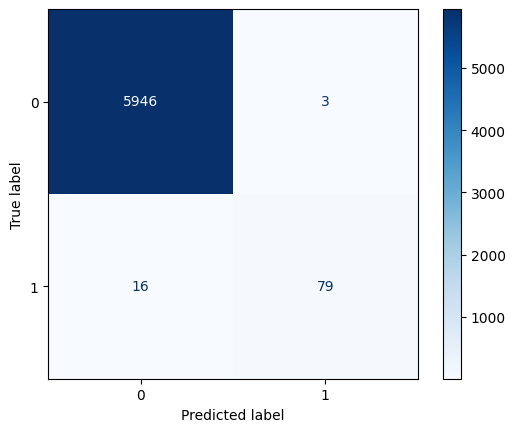

In [51]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. SMOTE on the FULL training set only — X_test is never touched
smote_final = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote_final.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_smote).value_counts().to_dict())

# 2. Fresh model, no scale_pos_weight — SMOTE already balanced the classes
final_model = XGBClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train_smote, y_train_smote)

# 3. Predict on the untouched test set
y_test_prob = final_model.predict_proba(X_test)[:, 1]

# 4. Apply the threshold you picked from the OOF analysis
chosen_threshold = 0.95
y_test_pred = (y_test_prob >= chosen_threshold).astype(int)

# 5. This is the number you actually report
print(classification_report(y_test, y_test_pred, digits=4))
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(cmap=plt.cm.Blues)
plt.show()